### **About Dataset:**
https://www.kaggle.com/datasets/shriyashjagtap/esg-and-financial-performance-dataset

**Description:**

This dataset simulates the financial and ESG (Environmental, Social, and Governance) performance of 1,000 global companies across 9 industries and 7 regions from 2015 to 2025. It contains realistic financial metrics (e.g., revenue, profit margins, market capitalization) alongside comprehensive ESG indicators, including carbon emissions, resource usage, and detailed ESG scores.

**Dataset Details:**

- Size: 11,000 rows × 16 columns
- Companies: 1,000 unique entities
- Period: Annual data from 2015 to 2025

## 1. DATA LOADING:

In [ ]:
import pandas as pd
df=pd.read_csv('/content/company_esg_financial_dataset.csv')
df.head(5)

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


##  2. EDA:

In [ ]:
df.shape

(11000, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

In [ ]:
df.describe()

,CompanyID,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,10000.000000,11000.000000,11000.000000,11000.000000,11000.000000,1.100000e+04,1.100000e+04,1.100000e+04
mean,500.500000,2020.000000,4670.850591,10.900455,13380.622236,4.830370,54.615273,56.416991,55.660582,51.767655,1.271462e+06,5.600442e+05,1.165839e+07
std,288.688113,3.162421,9969.954369,8.758711,39922.870373,9.424787,15.893937,26.767233,23.356152,25.323370,5.067760e+06,1.565686e+06,5.095836e+07
min,1.000000,2015.000000,35.900000,-20.000000,1.800000,-36.000000,6.300000,0.000000,0.000000,0.000000,2.042200e+03,1.021100e+03,5.105500e+03
25%,250.750000,2017.000000,938.775000,5.300000,1098.525000,-1.325000,44.100000,34.700000,37.600000,30.775000,1.228530e+05,6.488467e+04,3.069161e+05
50%,500.500000,2020.000000,1902.300000,10.500000,3096.450000,4.900000,54.600000,55.600000,55.150000,52.100000,2.920734e+05,2.038805e+05,1.221745e+06
75%,750.250000,2023.000000,4342.625000,16.300000,9995.500000,11.000000,65.600000,79.000000,73.800000,73.000000,7.407311e+05,5.251880e+05,5.616437e+06
max,1000.000000,2025.000000,180810.400000,50.000000,865271.700000,38.000000,98.800000,100.000000,100.000000,100.000000,1.741047e+08,5.223142e+07,1.741047e+09


Finding number of unique categories in each categorical column.

In [ ]:
for i in df.columns:
  if(df[i].dtype=='object'):
      print(i,": ", df[i].nunique())


CompanyName :  1000
Industry :  9
Region :  7


## 3. Data Cleaning

In [ ]:
df.duplicated().sum()

np.int64(0)

Dropping `CompanyID` and `CompanyName` columns from dataset as we do not required for now.

In [ ]:
df.drop(columns={'CompanyID','CompanyName'}, inplace=True)

This reduces the number of columns from 16 to 14.

In [ ]:
df.shape

(11000, 14)

Outliers can distort both your mean and variance, making any transformation (like log, Box-Cox, Yeo-Johnson) less effective or even invalid.
So, we will detect and handle ouliers.

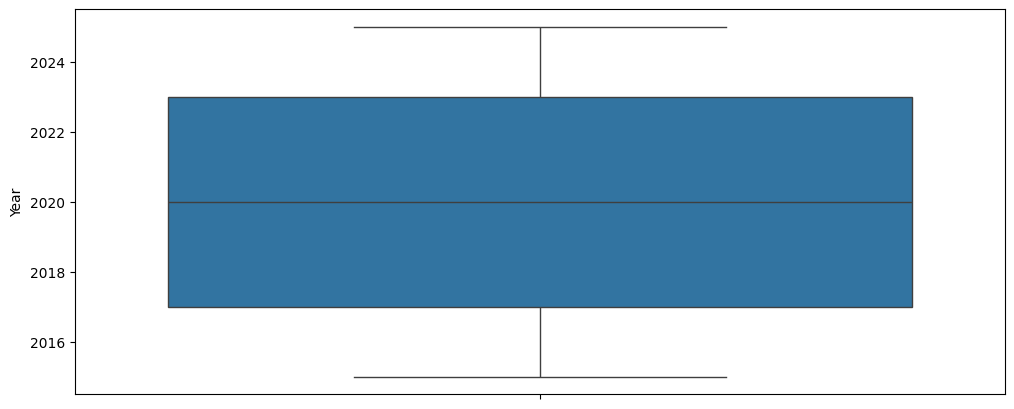

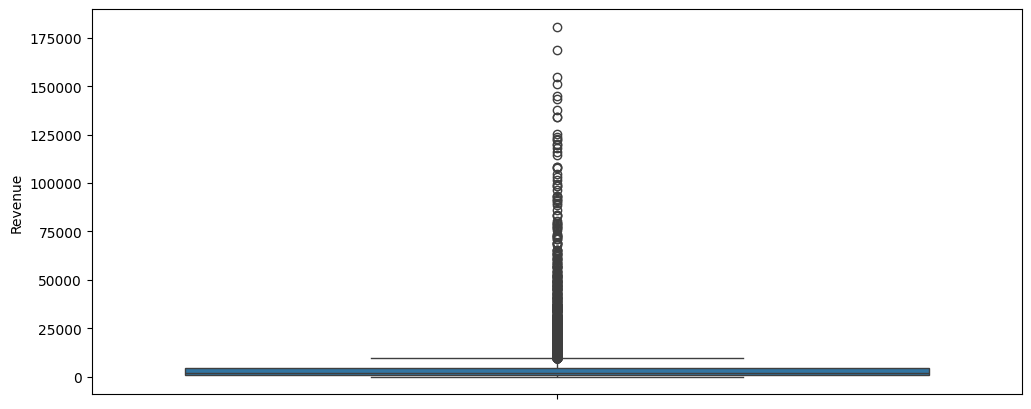

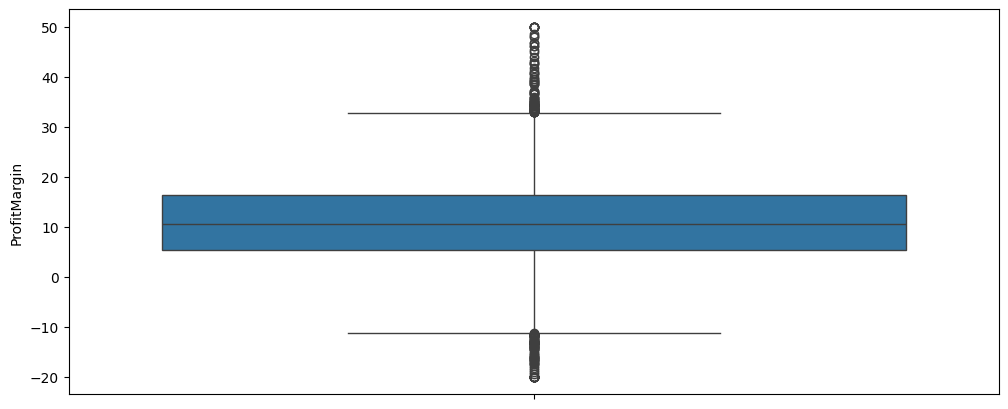

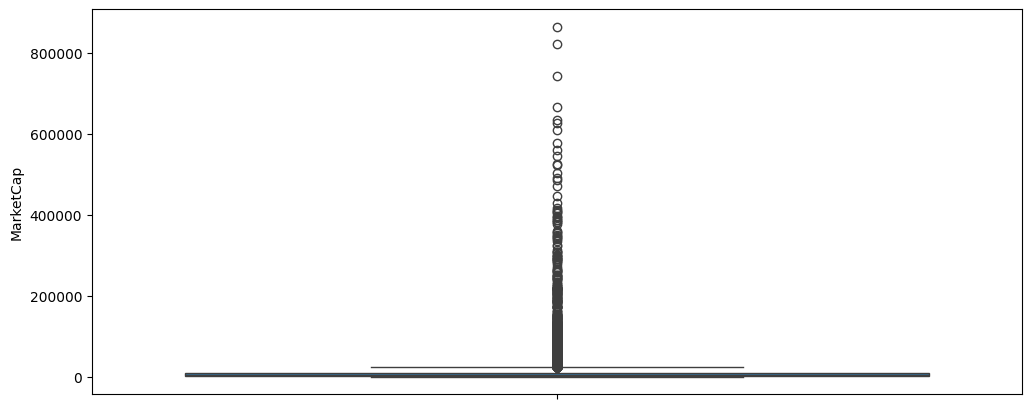

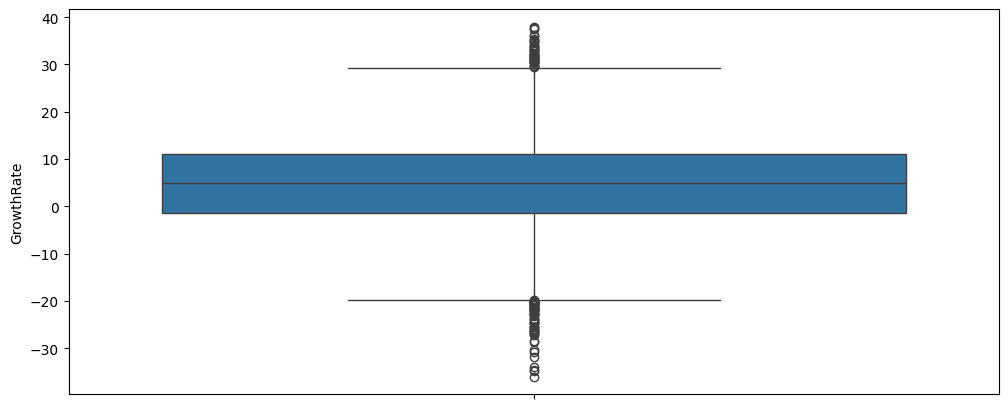

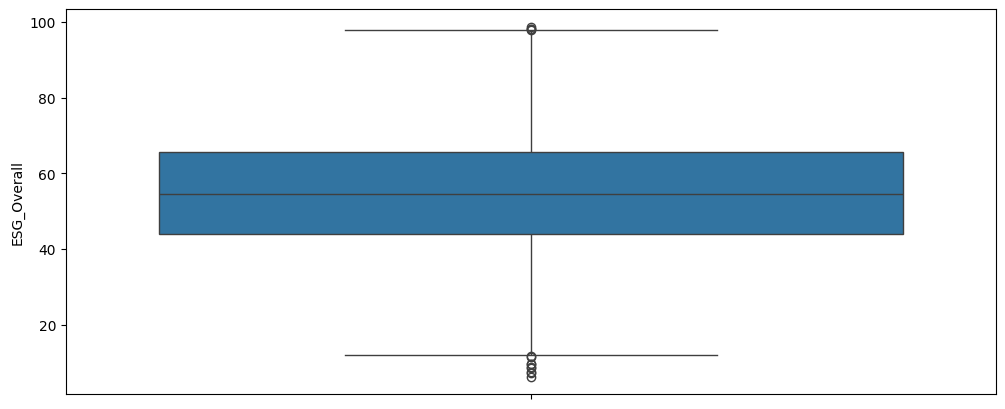

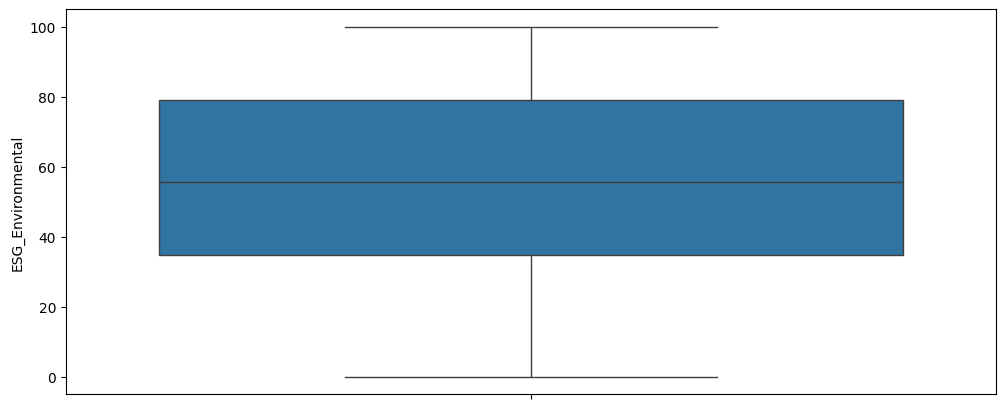

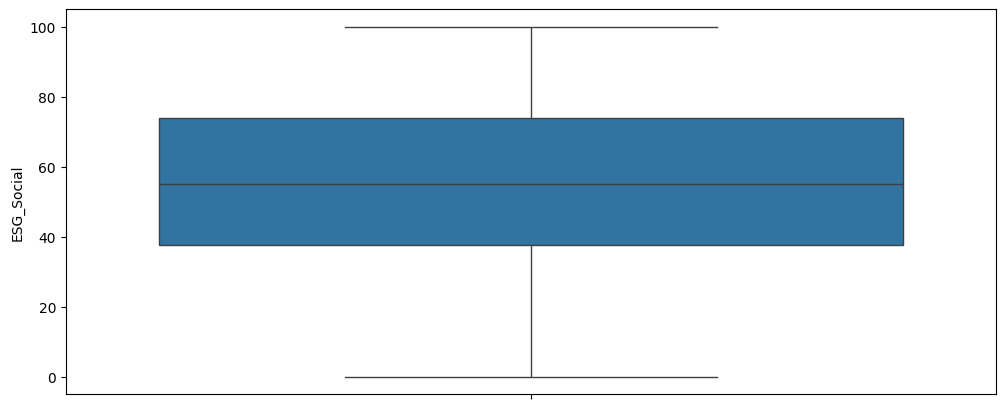

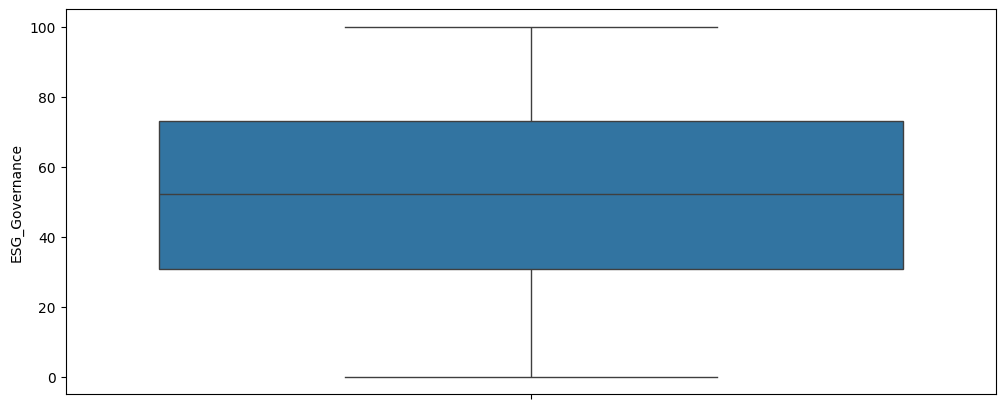

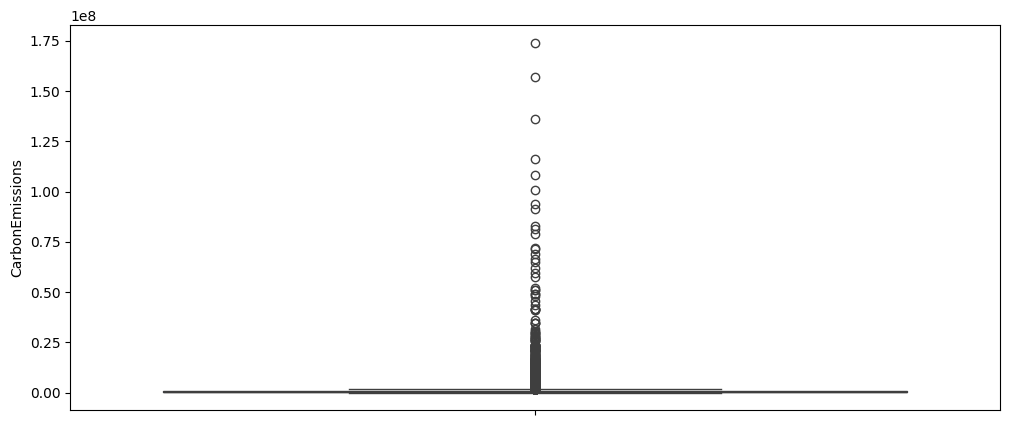

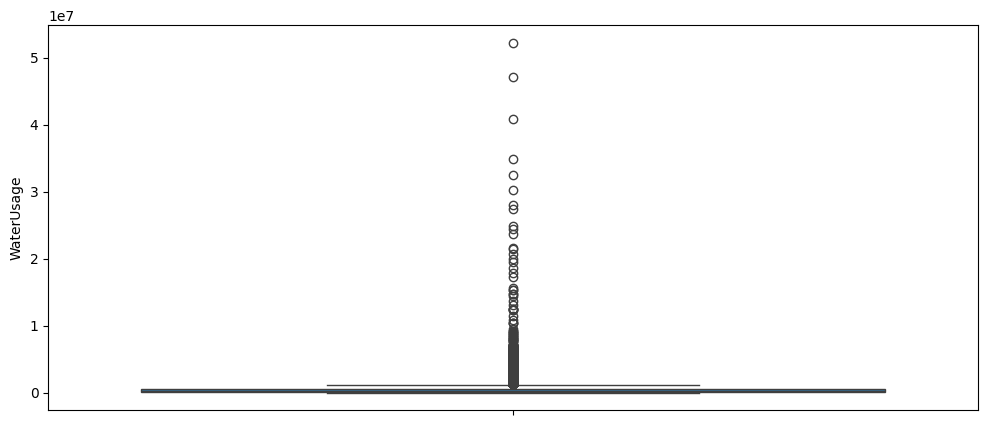

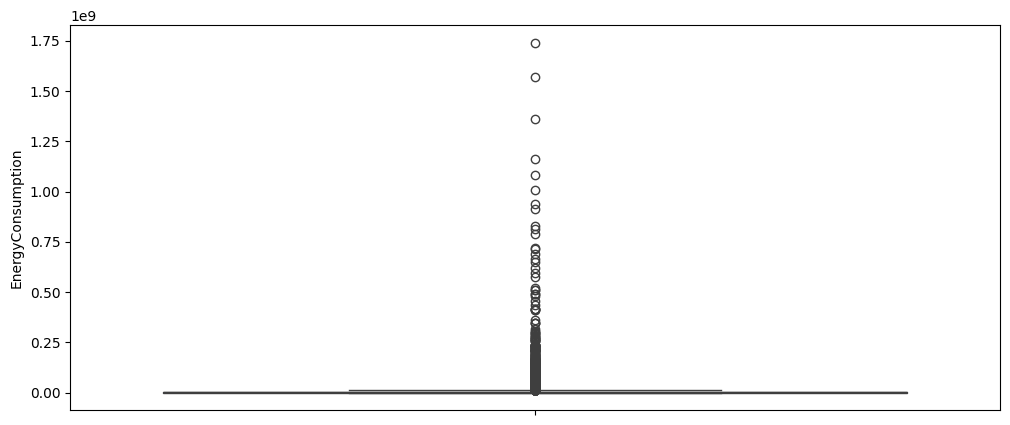

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
for i in df.columns:
  if(df[i].dtype=='int64' or df[i].dtype=='float64'):
    plt.figure(figsize=(12,5))
    sns.boxplot(df[i])

In [78]:
def cap_outliers(df):
    df = df.copy()

    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lb = q1 - 1.5 * iqr
        ub = q3 + 1.5 * iqr

        df[col] = df[col].clip(lower=lb, upper=ub)

    return df

df = cap_outliers(df)

After applying IQR method, we handled outliers in our dataset very clearly which we can see from the visual representation of boxplot.

/tmp/ipykernel_12867/2050693675.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,5))


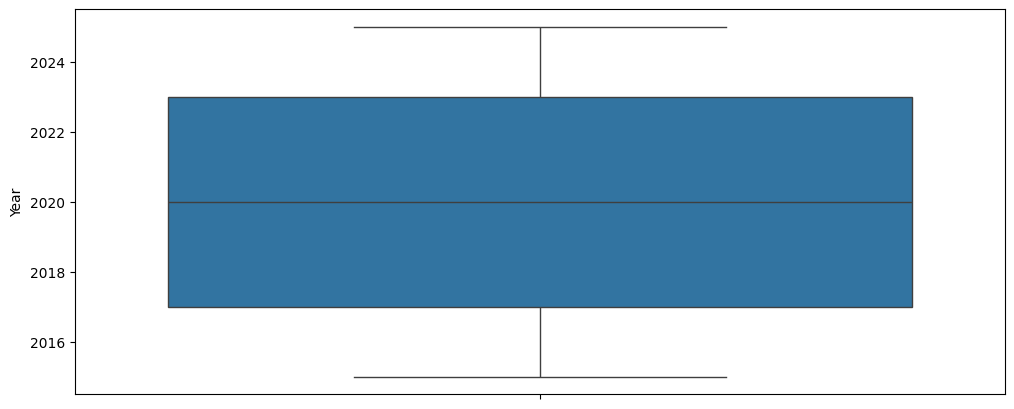

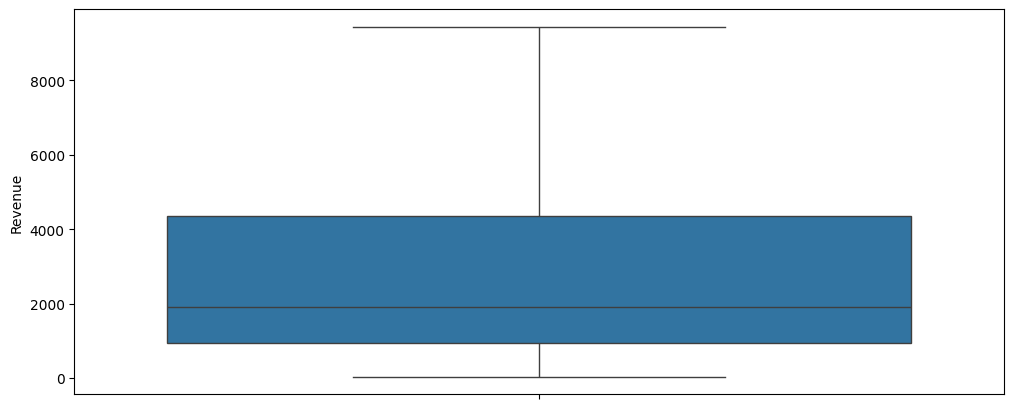

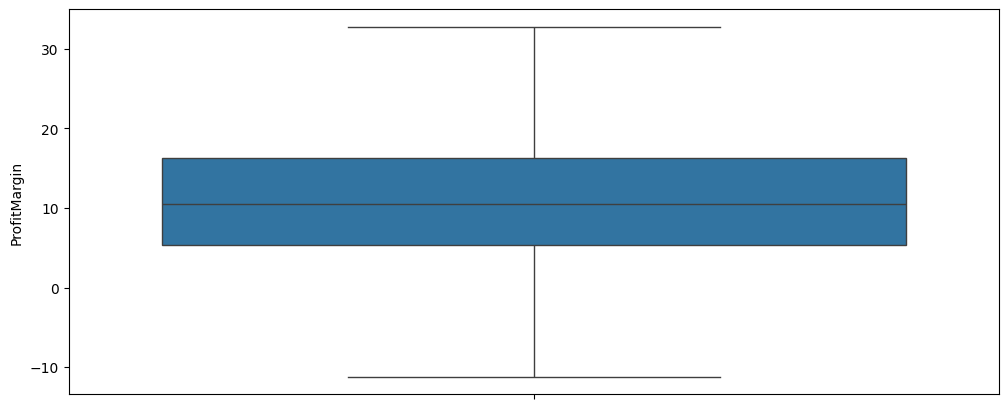

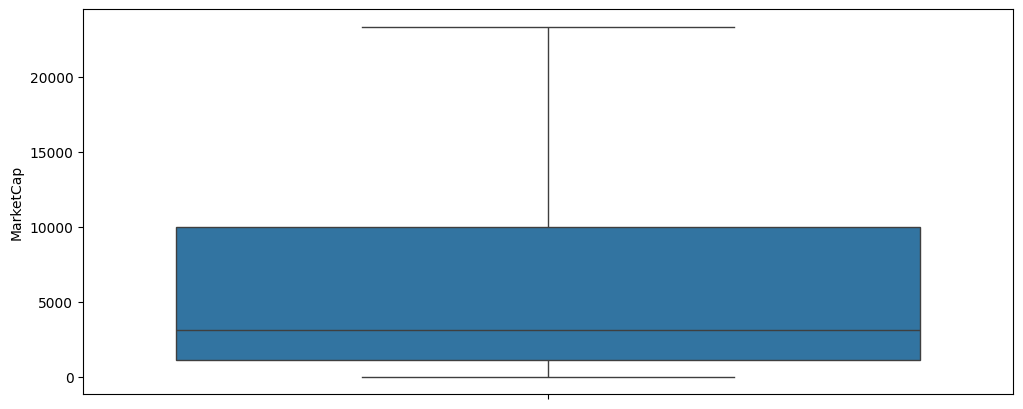

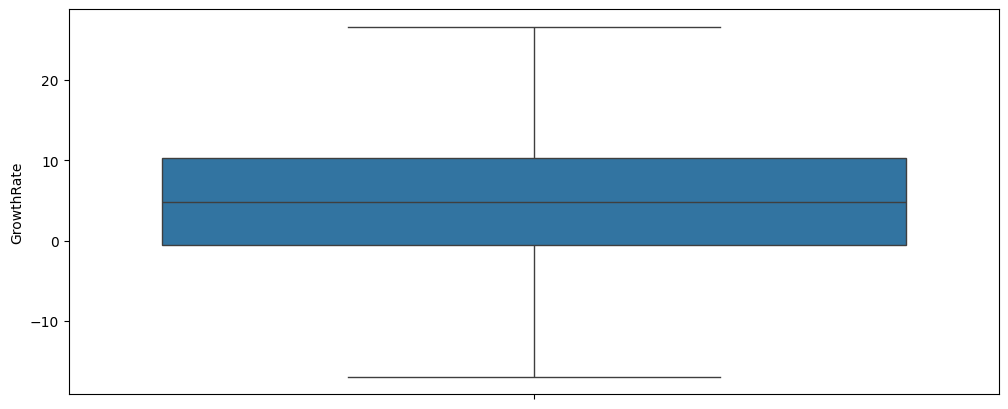

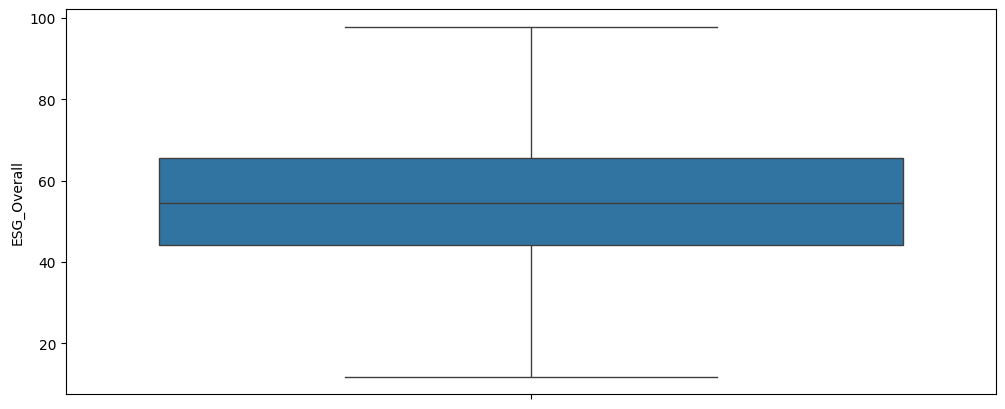

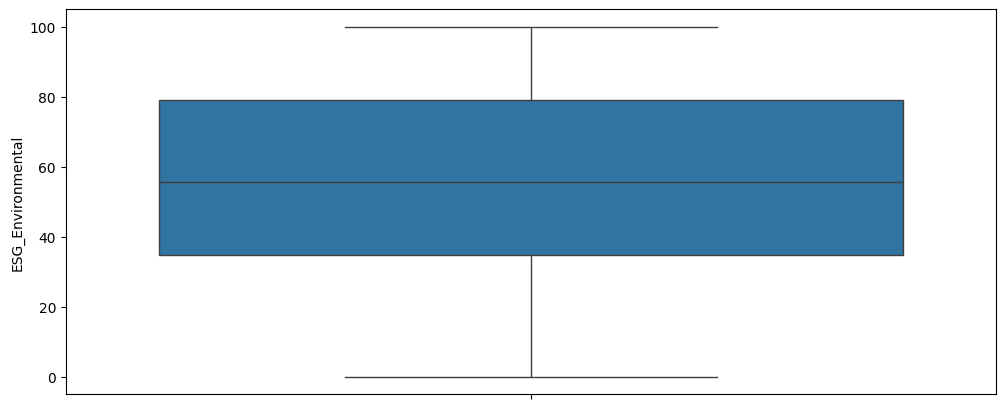

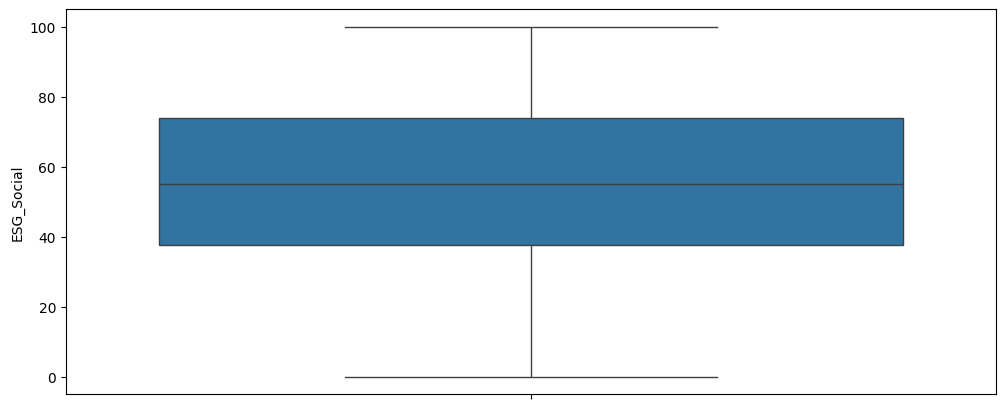

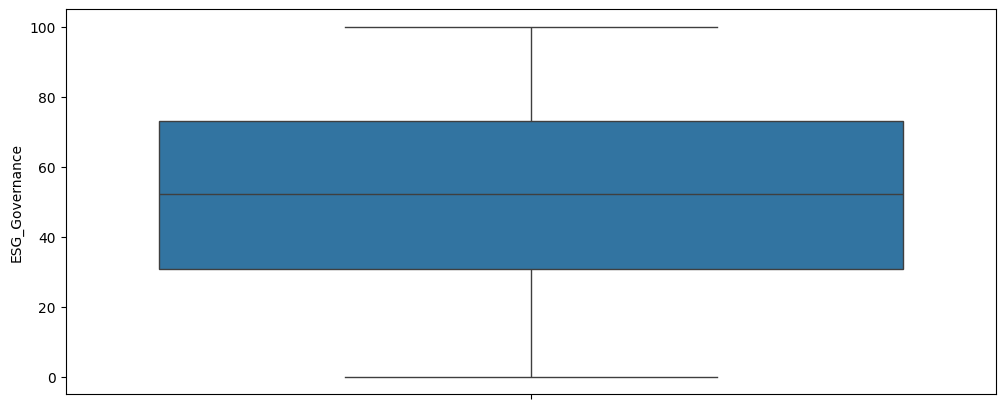

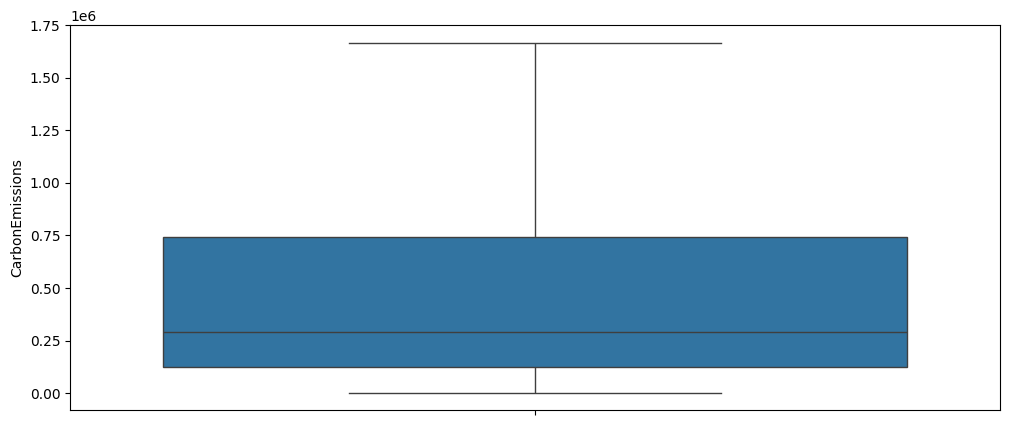

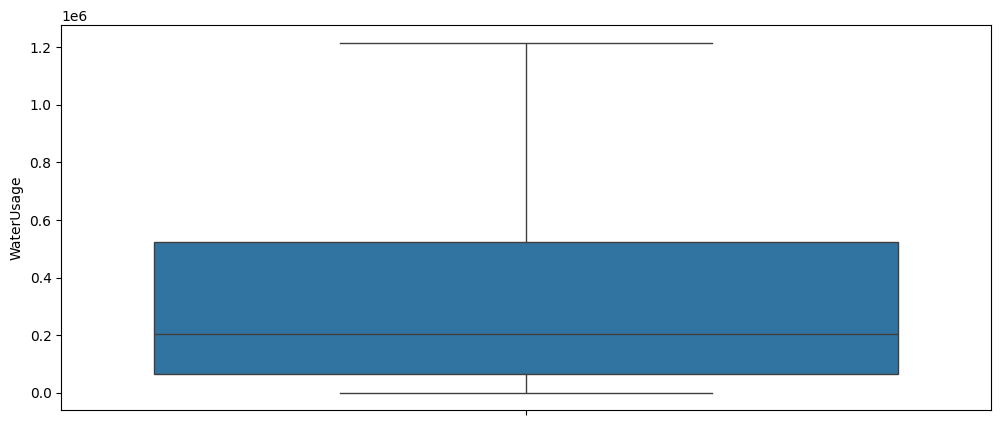

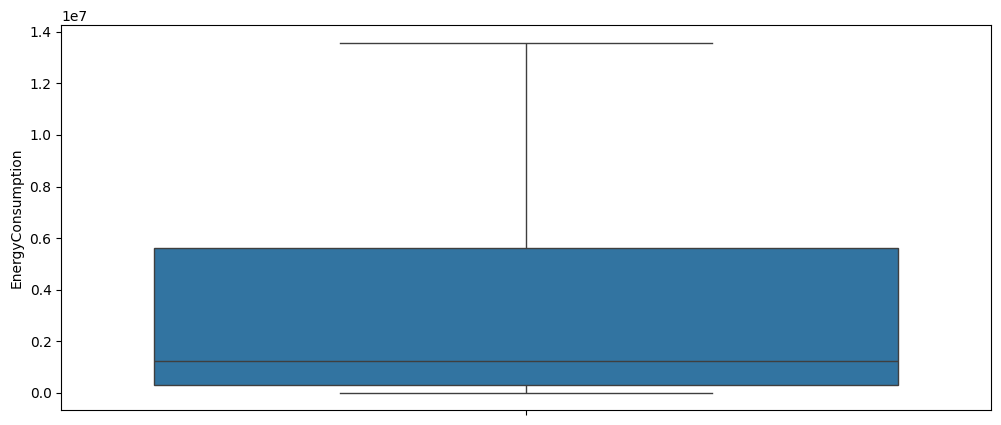

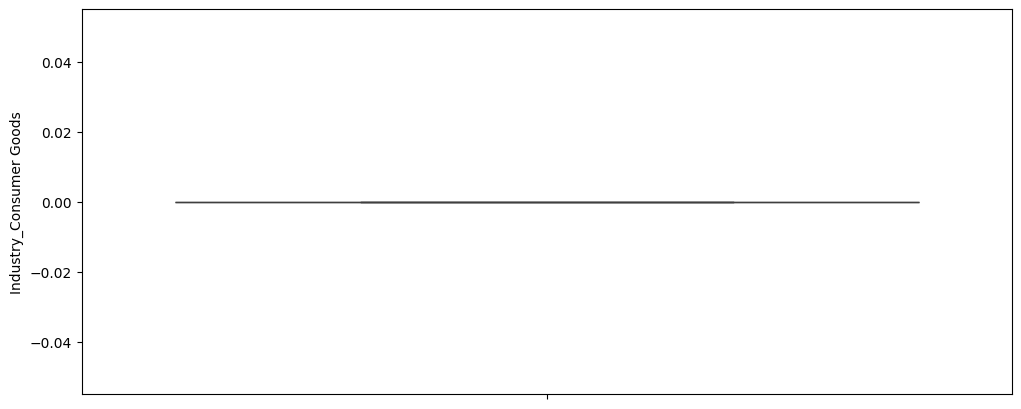

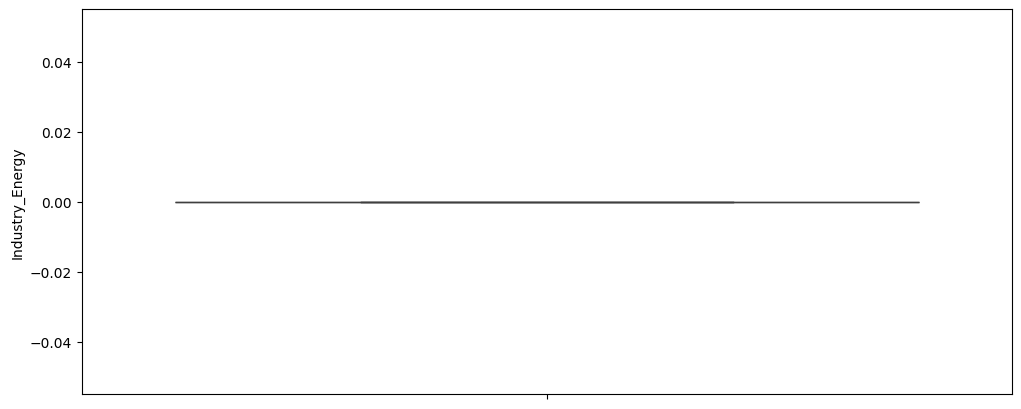

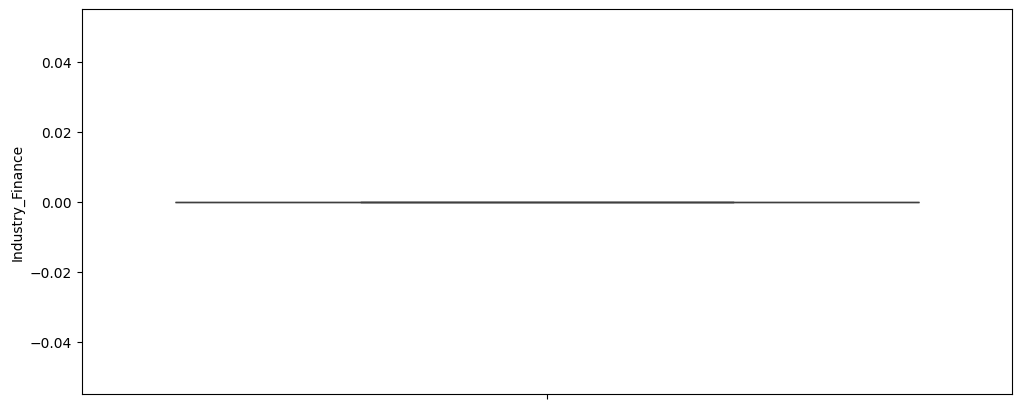

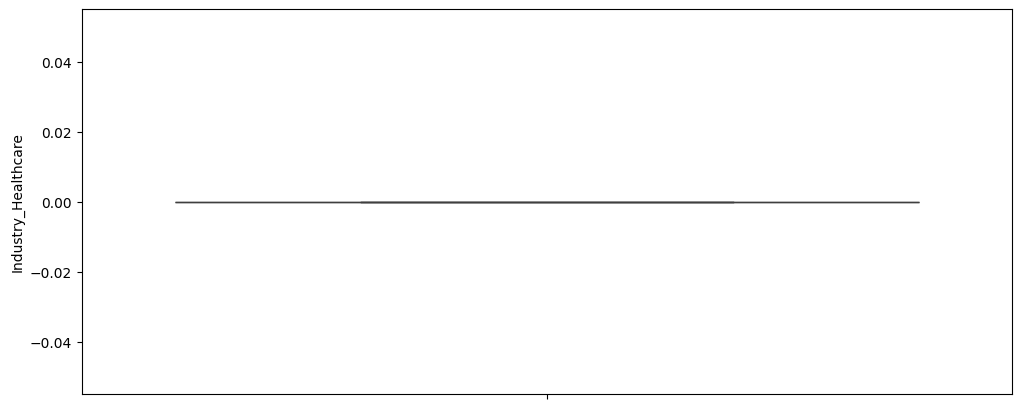

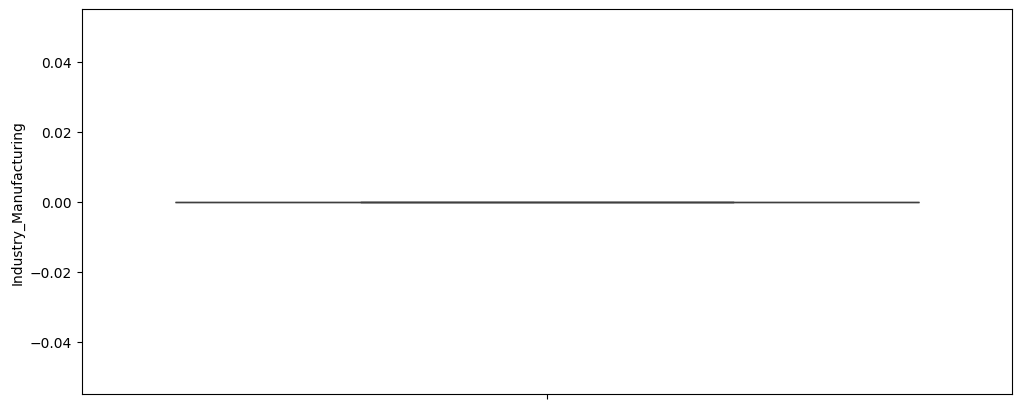

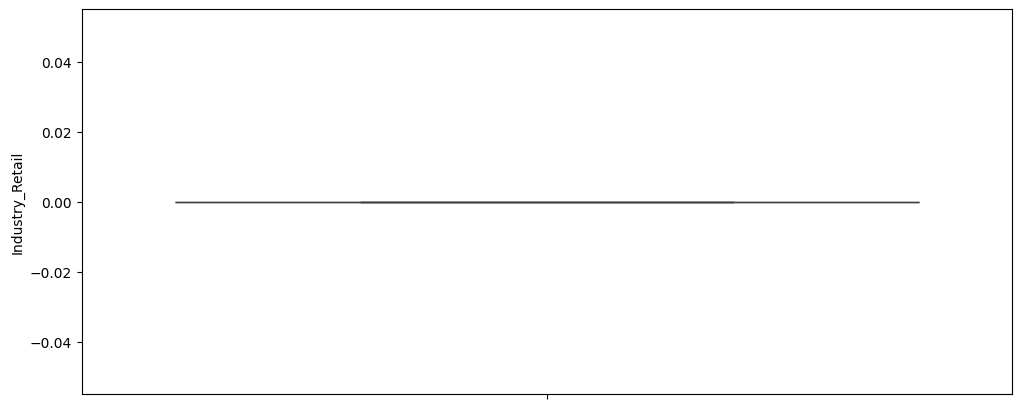

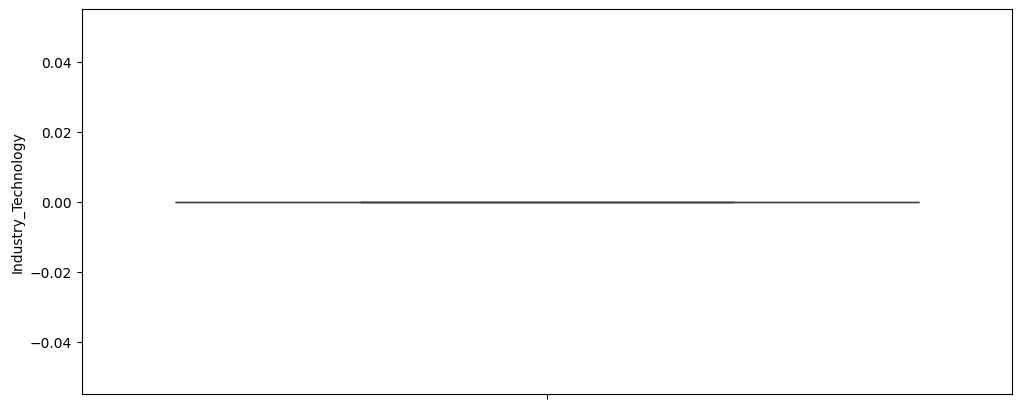

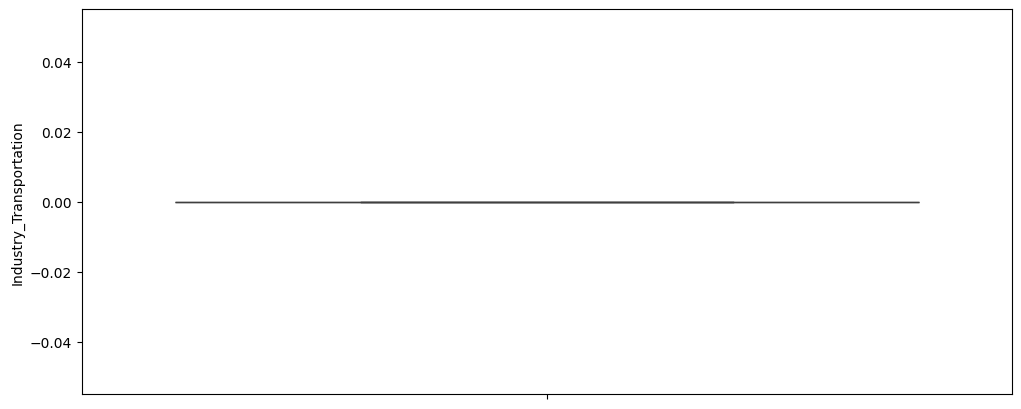

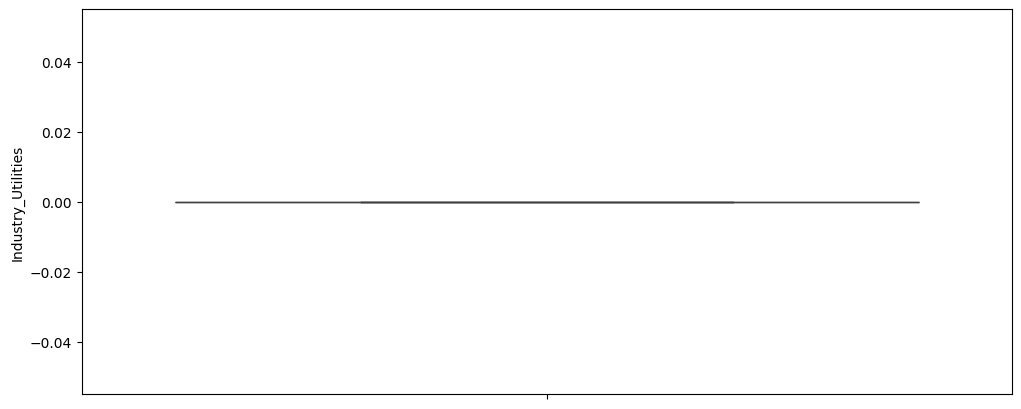

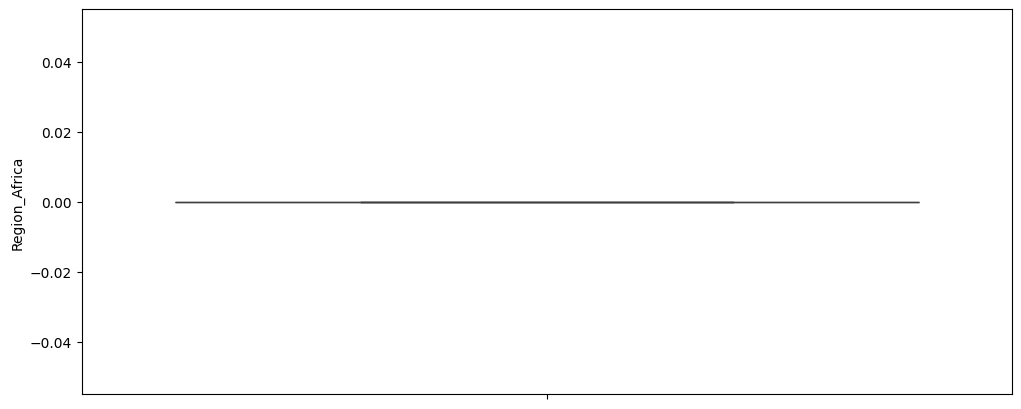

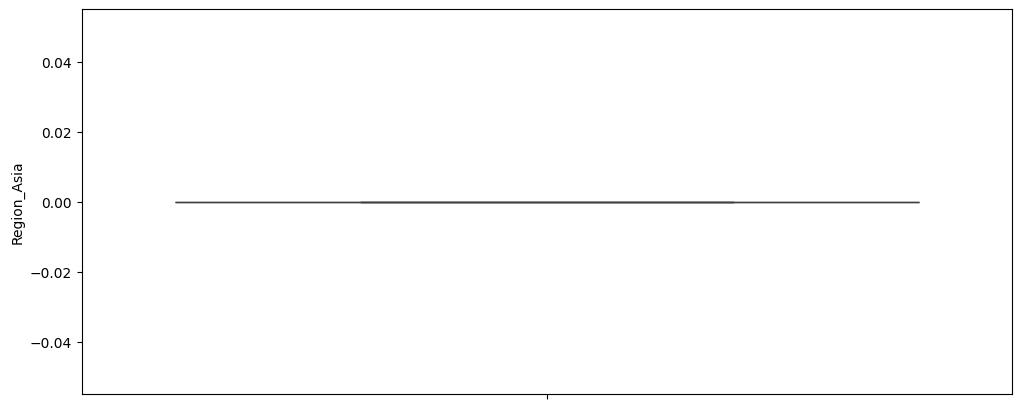

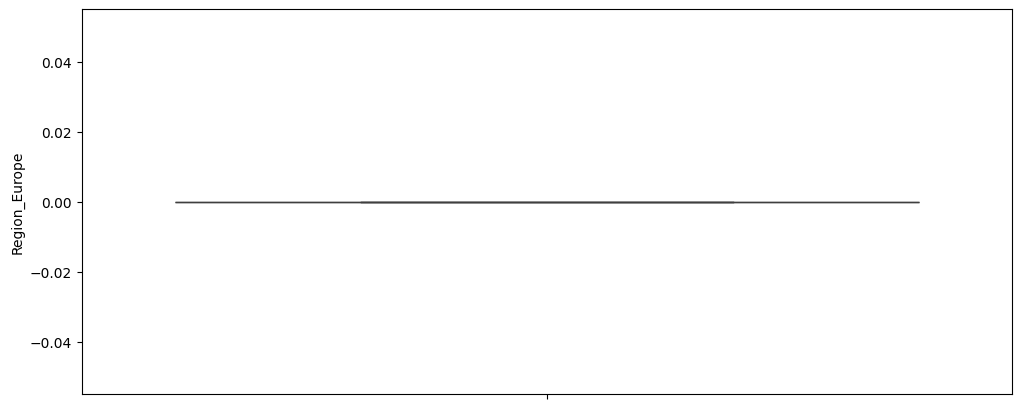

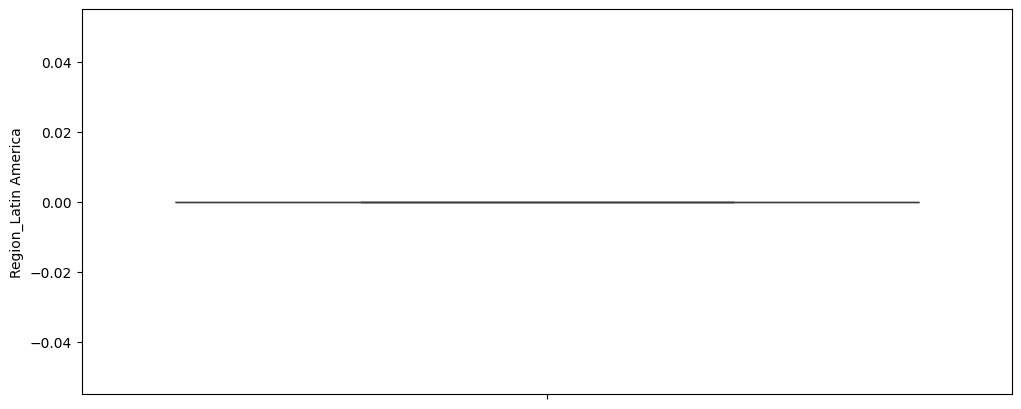

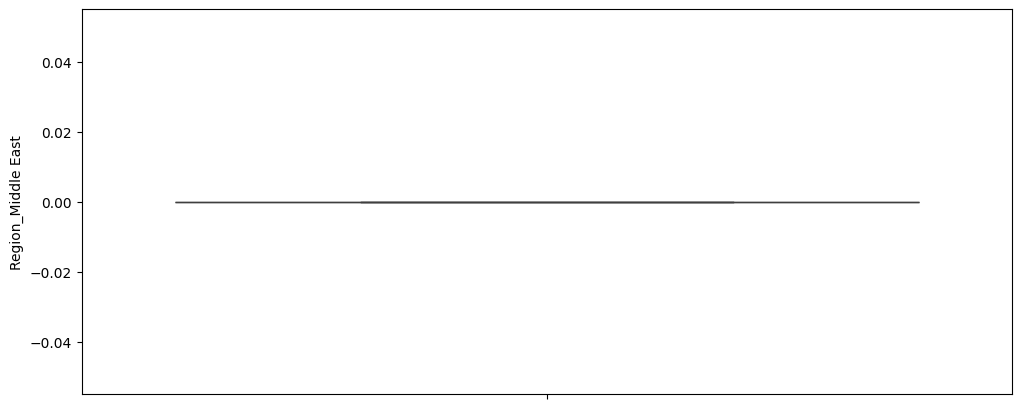

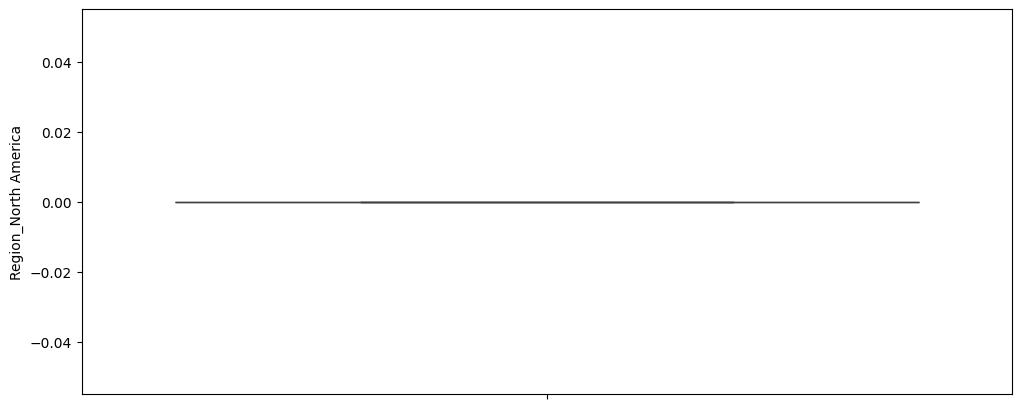

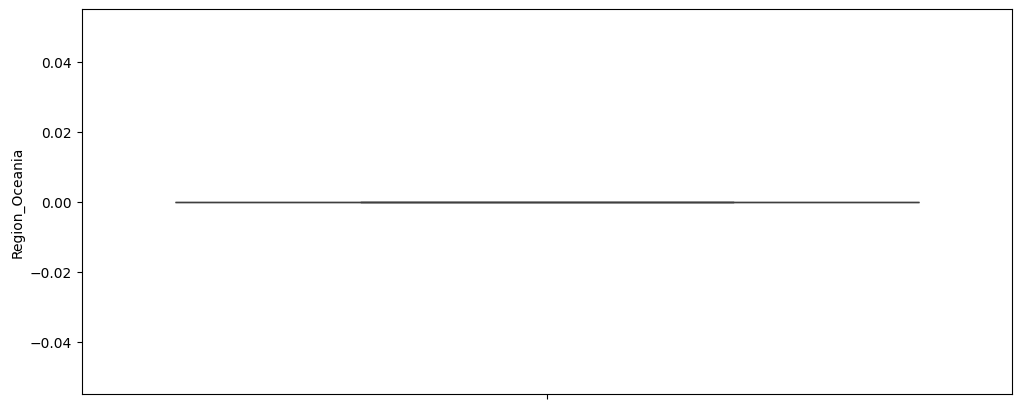

In [79]:
import matplotlib.pyplot as plt
for i in df.columns:
  if(df[i].dtype=='int64' or df[i].dtype=='float64'):
    plt.figure(figsize=(12,5))
    sns.boxplot(df[i])

In [80]:
df.isnull().sum()

,0
Year,0
Revenue,0
ProfitMargin,0
MarketCap,0
GrowthRate,0
ESG_Overall,0
ESG_Environmental,0
ESG_Social,0
ESG_Governance,0
CarbonEmissions,0


Fill null values in `GrowthRate` column with mean of it.

In [81]:
df['GrowthRate'].fillna(df['GrowthRate'].mean(),inplace=True)

/tmp/ipykernel_12867/2270073441.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GrowthRate'].fillna(df['GrowthRate'].mean(),inplace=True)


In [82]:
df.isnull().sum()

,0
Year,0
Revenue,0
ProfitMargin,0
MarketCap,0
GrowthRate,0
ESG_Overall,0
ESG_Environmental,0
ESG_Social,0
ESG_Governance,0
CarbonEmissions,0


# 4. Data Visualization



In [83]:
plt.figure(figsize=(12,3))
sns.countplot(x=df['Industry'], hue=df['Industry'])
plt.xticks(rotation=45)
plt.show()

KeyError: 'Industry'

<Figure size 1200x300 with 0 Axes>

Healthcare, Transportation and Consumer Goods are so prominent industries while Technology Industry is not taken so much in consideration in our dataset.

In [84]:
sns.countplot(x=df['Region'], hue=df['Region'])
plt.xticks(rotation=45)
plt.show()

KeyError: 'Region'

Most of the companies in our dataset are situated in Asia & ocenia and slightly less in Latin America, Africa, Europe and more.

In [85]:
# Average ESG_Overall by Industry
avg_scores = df.groupby('Industry')['ESG_Overall'].mean().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(x='Industry', y='ESG_Overall', data=avg_scores,palette='viridis')
plt.title("Average ESG Overall Score by Industry")
plt.xticks(rotation=45)
plt.show()


KeyError: 'Industry'

Finance companies have higher overall ESG scores, excelling in social and governance practices. Being less environmentally intensive, their ESG_Environmental is lower, but they focus on employee well-being and strong governance.

## 5. Data Preprocesssing

In [86]:
# Apply One hot encoding on categorical columns.
df = pd.get_dummies(df, columns=['Industry', 'Region'], dtype='int')


KeyError: "None of [Index(['Industry', 'Region'], dtype='object')] are in the [columns]"

In [87]:
df.head()

,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,...,Industry_Technology,Industry_Transportation,Industry_Utilities,Region_Africa,Region_Asia,Region_Europe,Region_Latin America,Region_Middle East,Region_North America,Region_Oceania
0,2015,459.2,6.0,337.5,4.842861,57.0,60.7,33.5,76.8,35577.4,...,0,0,0,0,0,0,0,0,0,0
1,2016,473.8,4.6,366.6,3.200000,56.7,58.9,32.8,78.5,37314.7,...,0,0,0,0,0,0,0,0,0,0
2,2017,564.9,5.2,313.4,19.200000,56.5,57.6,34.0,77.8,45006.4,...,0,0,0,0,0,0,0,0,0,0
3,2018,558.4,4.3,283.0,-1.100000,58.0,62.3,33.4,78.3,42650.1,...,0,0,0,0,0,0,0,0,0,0
4,2019,554.5,4.9,538.1,-0.700000,56.6,63.7,30.0,76.1,41799.4,...,0,0,0,0,0,0,0,0,0,0


## 6. Data Splitting

In [88]:
X = df.drop(columns=['Revenue'])
y=df['Revenue']
X

,Year,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,...,Industry_Technology,Industry_Transportation,Industry_Utilities,Region_Africa,Region_Asia,Region_Europe,Region_Latin America,Region_Middle East,Region_North America,Region_Oceania
0,2015,6.0,337.5,4.842861,57.0,60.7,33.5,76.8,35577.4,17788.7,...,0,0,0,0,0,0,0,0,0,0
1,2016,4.6,366.6,3.200000,56.7,58.9,32.8,78.5,37314.7,18657.4,...,0,0,0,0,0,0,0,0,0,0
2,2017,5.2,313.4,19.200000,56.5,57.6,34.0,77.8,45006.4,22503.2,...,0,0,0,0,0,0,0,0,0,0
3,2018,4.3,283.0,-1.100000,58.0,62.3,33.4,78.3,42650.1,21325.1,...,0,0,0,0,0,0,0,0,0,0
4,2019,4.9,538.1,-0.700000,56.6,63.7,30.0,76.1,41799.4,20899.7,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10995,2021,21.7,14416.7,0.400000,52.2,67.2,46.3,43.1,498875.8,623594.7,...,0,0,0,0,0,0,0,0,0,0
10996,2022,21.4,8078.9,2.900000,51.9,68.7,44.7,42.3,506013.7,632517.1,...,0,0,0,0,0,0,0,0,0,0
10997,2023,17.1,13263.4,-2.900000,52.9,72.4,43.1,43.2,473561.5,591951.9,...,0,0,0,0,0,0,0,0,0,0
10998,2024,15.7,6960.1,-6.800000,52.0,72.4,40.5,42.9,441310.9,551638.6,...,0,0,0,0,0,0,0,0,0,0


In [89]:
# Apply standard scaling to scale all numerical column values within certain range.

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
numeric_cols = [col for col in X.columns
                if not col.startswith('Industry_') and not col.startswith('Region_')]

# Make a copy to avoid altering the original DataFrame
X_scaled = X.copy()

# Scale only numeric columns
scaler = StandardScaler()
X_scaled[numeric_cols] = scaler.fit_transform(X_scaled[numeric_cols])

In [90]:
from sklearn.model_selection import train_test_split
import numpy as np
X_train, X_test, y_train, y_test=train_test_split(X_scaled,y,test_size=0.2, random_state=42)

y_train = np.log1p(y_train)
y_test = np.log1p(y_test)


In [91]:
X_train

,Year,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,...,Industry_Technology,Industry_Transportation,Industry_Utilities,Region_Africa,Region_Asia,Region_Europe,Region_Latin America,Region_Middle East,Region_North America,Region_Oceania
10735,1.581139,0.800834,-0.609560,-1.157800,-1.700692,-1.106515,-0.550654,-1.519127,0.867266,0.656138,...,0,0,0,0,0,0,0,0,0,0
5937,0.948683,-0.351596,-0.620394,-0.028524,1.245271,0.851192,1.898491,-0.306753,0.846234,0.637983,...,0,0,0,0,0,0,0,0,0,0
7642,0.948683,-0.539748,-0.796547,-1.055139,0.080734,0.189905,-0.066820,0.005226,-0.613202,-0.265675,...,0,0,0,0,0,0,0,0,0,0
3328,0.316228,2.188454,0.064687,-2.344110,0.294757,-0.990696,0.806651,0.862181,1.398179,0.048165,...,0,0,0,0,0,0,0,0,0,0
8681,-0.948683,1.471125,1.038630,-0.610272,-0.095520,0.910969,-0.931728,-0.275160,-0.802097,-0.815125,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,-0.632456,-1.668659,-0.770549,1.055125,-1.606270,0.279571,-1.642493,-1.811360,-0.760475,-0.886181,...,0,0,0,0,0,0,0,0,0,0
5191,1.581139,0.389252,0.346472,1.089345,2.579767,1.497534,1.864237,1.561172,-0.491107,-0.264645,...,0,0,0,0,0,0,0,0,0,0
5390,-1.581139,0.283417,-0.782047,-0.000821,-1.656628,-0.953335,-0.897474,-1.282180,-0.278713,-0.775283,...,0,0,0,0,0,0,0,0,0,0
860,-0.948683,1.188897,2.078229,-1.009511,0.370295,0.574722,-0.841811,0.870080,-0.096359,0.280561,...,0,0,0,0,0,0,0,0,0,0


In [92]:
y_train

,Revenue
10735,7.105212
5937,7.543379
7642,6.738271
3328,7.156723
8681,8.905905
...,...
5734,5.551408
5191,8.508112
5390,6.451260
860,8.817105


Catboost installation for futher usage.


In [93]:
!pip install catboost


## 7. Model Selection

Apply all the regression models and selecting the models which shows good performance on both training and testing dataset.

In [94]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    AdaBoostRegressor, ExtraTreesRegressor,
    VotingRegressor, StackingRegressor
)
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    'Linear Regression' : LinearRegression(),
    'Lasso' : Lasso(),
    'Ridge' : Ridge(),
    'ElasticNet' : ElasticNet(),
    'Support Vector Regressor' : SVR(),
    'Gradient Boosting Regressor' : GradientBoostingRegressor(),
    'Extra Trees Regressor' : ExtraTreesRegressor(),
    'Random Forest Regressor' : RandomForestRegressor(),
    'AdaBoost Regressor' : AdaBoostRegressor(),
    'XGBoost Regressor' : XGBRegressor(),
    'K-Neighbors Regressor' : KNeighborsRegressor(),
    'Decision Tree' : DecisionTreeRegressor(),
    'LightGBM Regressor' : LGBMRegressor(),
    'CatBoost Regressor' : CatBoostRegressor(verbose=0)
}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    y_test_pred = np.expm1(y_pred)

    print(f'\n✨ {name}')
    print('💠 Training Performance:')
    print(f' - MSE : {mean_squared_error(y_train, y_train_pred):.2f}')
    print(f' - MAE : {mean_absolute_error(y_train, y_train_pred):.2f}')
    print(f' - R² : {r2_score(y_train, y_train_pred)*100:.2f}')

    print('💠 Testing Performance:')
    print(f' - MSE : {mean_squared_error(y_test, y_test_pred):.2f}')
    print(f' - MAE : {mean_absolute_error(y_test, y_test_pred):.2f}')
    print(f' - R² : {r2_score(y_test, y_test_pred)*100:.2f}')



✨ Linear Regression
💠 Training Performance:
 - MSE : 0.26
 - MAE : 0.38
 - R² : 74.51
💠 Testing Performance:
 - MSE : 30107257.47
 - MAE : 3207.24
 - R² : -2950331560.94

✨ Lasso
💠 Training Performance:
 - MSE : 1.00
 - MAE : 0.84
 - R² : 0.00
💠 Testing Performance:
 - MSE : 3968866.72
 - MAE : 1992.20
 - R² : -388925166.72

✨ Ridge
💠 Training Performance:
 - MSE : 0.26
 - MAE : 0.38
 - R² : 74.51
💠 Testing Performance:
 - MSE : 30084330.39
 - MAE : 3207.40
 - R² : -2948084844.08

✨ ElasticNet
💠 Training Performance:
 - MSE : 0.74
 - MAE : 0.71
 - R² : 26.37
💠 Testing Performance:
 - MSE : 4281416.77
 - MAE : 2022.82
 - R² : -419553207.29

✨ Support Vector Regressor
💠 Training Performance:
 - MSE : 0.08
 - MAE : 0.19
 - R² : 92.16
💠 Testing Performance:
 - MSE : 16398168.78
 - MAE : 2945.40
 - R² : -1606922635.23

✨ Gradient Boosting Regressor
💠 Training Performance:
 - MSE : 0.05
 - MAE : 0.18
 - R² : 94.58
💠 Testing Performance:
 - MSE : 16137266.72
 - MAE : 2951.65
 - R² : -1581355

## 7. Hyperparameter Tuning:
Tuning the best models to improve their performance.

In [95]:
# ✅ Import necessary libraries
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# ✅ Models
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.linear_model import Ridge

# ✅ Define models dictionary with params
models_with_params = {
    'CatBoost': (CatBoostRegressor(verbose=0), {
        'depth': [6, 8, 10],
        'learning_rate': [0.01, 0.05, 0.1],
        'iterations': [300, 500, 800],
        'l2_leaf_reg': [1, 3, 5],
        'subsample': [0.8, 1.0]
    }),
    'LightGBM': (LGBMRegressor(), {
        'num_leaves': [31, 50, 100],
        'max_depth': [-1, 6, 10],
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [300, 500, 800],
        'subsample': [0.7, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.9, 1.0]
    }),
    'XGBoost': (XGBRegressor(), {
        'n_estimators': [300, 500, 800],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [4, 6, 10],
        'subsample': [0.7, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.9, 1.0],
        'gamma': [0, 0.1, 0.3],
        'reg_lambda': [1, 3, 5]
    }),
    'Random Forest': (RandomForestRegressor(), {
        'n_estimators': [200, 400, 600],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }),
    'Gradient Boosting': (GradientBoostingRegressor(), {
        'n_estimators': [200, 400, 600],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
        'loss': ['squared_error', 'huber']
    }),
    'Decision Tree': ( DecisionTreeRegressor(), {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['auto', 'sqrt', 'log2']
    }),
    'K-Neighbors': (KNeighborsRegressor(), {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
    }),
    'Extra Trees': (ExtraTreesRegressor(), {
        'n_estimators': [200, 400, 600],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['auto', 'sqrt', 'log2']
    })
}

best_models = {}   # store best estimators
results = []       # store performance summary

for name, (model, params) in models_with_params.items():
    print(f"\n🚀 Tuning {name}...")

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=25,
        scoring='r2',
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_
    best_params = random_search.best_params_
    print(f"Best Parameters: {best_params}")

    # Evaluate on test set
    y_pred = best_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    best_models[name] = best_model
    results.append({'Model': name, 'Best_Params': best_params, 'R2_Score': r2})

# Show tuning results
results_df = pd.DataFrame(results).sort_values(by='R2_Score', ascending=False)
print("\n🎯 Individual Model Results:")
print(results_df)



🚀 Tuning CatBoost...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters: {'subsample': 1.0, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 800, 'depth': 8}

🚀 Tuning LightGBM...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001237 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2560
[LightGBM] [Info] Number of data points in the train set: 8800, number of used features: 11
[LightGBM] [Info] Start training from score 7.601284
Best Parameters: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 800, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

🚀 Tuning XGBoost...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters: {'subsample': 0.9, 'reg_lambda': 3, 'n_estimators': 800, 'max_de

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
35 fits failed out of a total of 125.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

Best Parameters: {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

🚀 Tuning K-Neighbors...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'weights': 'distance', 'n_neighbors': 3, 'algorithm': 'auto'}

🚀 Tuning Extra Trees...
Fitting 5 folds for each of 25 candidates, totalling 125 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
50 fits failed out of a total of 125.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

Best Parameters: {'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}

🎯 Individual Model Results:
               Model                                        Best_Params  \
0           CatBoost  {'subsample': 1.0, 'learning_rate': 0.1, 'l2_l...   
2            XGBoost  {'subsample': 0.9, 'reg_lambda': 3, 'n_estimat...   
1           LightGBM  {'subsample': 1.0, 'num_leaves': 31, 'n_estima...   
4  Gradient Boosting  {'subsample': 0.8, 'n_estimators': 600, 'max_d...   
7        Extra Trees  {'n_estimators': 600, 'min_samples_split': 2, ...   
3      Random Forest  {'n_estimators': 200, 'min_samples_split': 5, ...   
6        K-Neighbors  {'weights': 'distance', 'n_neighbors': 3, 'alg...   
5      Decision Tree  {'min_samples_split': 10, 'min_samples_leaf': ...   

   R2_Score  
0  0.986149  
2  0.983109  
1  0.982635  
4  0.980743  
7  0.957585  
3  0.956222  
6  0.873916  
5  0.861281  


In [96]:
results

[{'Model': 'CatBoost',
  'Best_Params': {'subsample': 1.0,
   'learning_rate': 0.1,
   'l2_leaf_reg': 3,
   'iterations': 800,
   'depth': 8},
  'R2_Score': 0.9861494102443132},
 {'Model': 'LightGBM',
  'Best_Params': {'subsample': 1.0,
   'num_leaves': 31,
   'n_estimators': 800,
   'max_depth': -1,
   'learning_rate': 0.05,
   'colsample_bytree': 1.0},
  'R2_Score': 0.9826354639639837},
 {'Model': 'XGBoost',
  'Best_Params': {'subsample': 0.9,
   'reg_lambda': 3,
   'n_estimators': 800,
   'max_depth': 6,
   'learning_rate': 0.1,
   'gamma': 0,
   'colsample_bytree': 0.7},
  'R2_Score': 0.9831086971960071},
 {'Model': 'Random Forest',
  'Best_Params': {'n_estimators': 200,
   'min_samples_split': 5,
   'min_samples_leaf': 1,
   'max_features': 'sqrt',
   'max_depth': 20},
  'R2_Score': 0.9562218195873453},
 {'Model': 'Gradient Boosting',
  'Best_Params': {'subsample': 0.8,
   'n_estimators': 600,
   'max_depth': 7,
   'loss': 'huber',
   'learning_rate': 0.1},
  'R2_Score': 0.9807431

In [97]:
# Get top 3 model names
top_models = results_df.head(3)['Model'].values
print("\n🔥 Top 3 Models for Ensemble:", top_models)

# Retrieve their tuned versions
m1, m2, m3 = [best_models[name] for name in top_models]

# ✅ Voting Regressor
voting_regressor = VotingRegressor(
    estimators=[
        ('model1', m1),
        ('model2', m2),
        ('model3', m3)
    ],
    weights=[3, 2, 1]  # or adjust manually if needed
)

# ✅ Stacking Regressor
stacking_regressor = StackingRegressor(
    estimators=[
        ('model1', m1),
        ('model2', m2),
        ('model3', m3)
    ],
    final_estimator = GradientBoostingRegressor()
)



🔥 Top 3 Models for Ensemble: ['CatBoost' 'XGBoost' 'LightGBM']


## 8. Ensembling Models:

Ensembling high performing models into voting and stacking regressor where Combining predictions from multiple well-performing models reduces individual model errors, leading to better overall performance and higher R² / lower RMSE.

In [98]:
# Fit both ensembles
voting_regressor.fit(X_train, y_train)
stacking_regressor.fit(X_train, y_train)

# Predictions
y_pred_vote = voting_regressor.predict(X_test)
y_pred_stack = stacking_regressor.predict(X_test)

# Scores
r2_train_stack=r2_score(y_train, stacking_regressor.predict(X_train))
r2_train_vote=r2_score(y_train, voting_regressor.predict(X_train))
r2_vote = r2_score(y_test, y_pred_vote)
r2_stack = r2_score(y_test, y_pred_stack)

# Add to results
results_df = pd.concat([results_df, pd.DataFrame([
    {'Model': 'Voting Regressor', 'Best_Params': 'From Tuned Models', 'R2_Score': r2_vote},
    {'Model': 'Stacking Regressor', 'Best_Params': 'From Tuned Models', 'R2_Score': r2_stack}
])])

print("\n✅ Final Model Comparison:")
print(results_df.sort_values(by='R2_Score', ascending=False))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001511 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2560
[LightGBM] [Info] Number of data points in the train set: 8800, number of used features: 11
[LightGBM] [Info] Start training from score 7.601284
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001280 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2560
[LightGBM] [Info] Number of data points in the train set: 8800, number of used features: 11
[LightGBM] [Info] Start training from score 7.601284
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of test

In [99]:
print("Training R2 score: ", r2_train_stack)
print("Testing R2 score: ", r2_stack)


Training R2 score:  0.9977172899227084
Testing R2 score:  0.9864397281969801


In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = stacking_regressor.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

MAE: 0.07938988106425347
RMSE: 0.11763440920944869


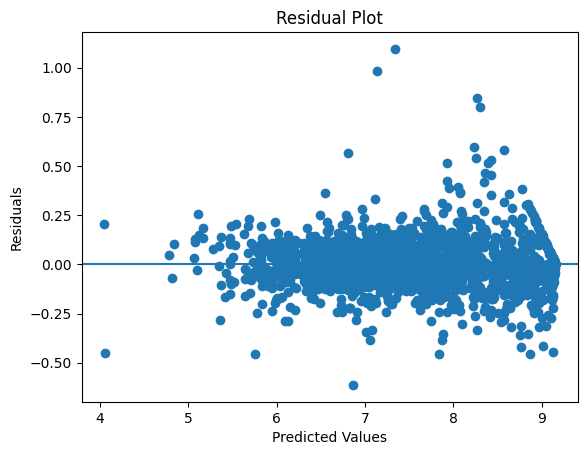

In [101]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Best performing model: [StackingRegressor]

Training R2 score: 0.99947

Testing R2 score: 0.987500

This shows that our model is not overfitting and understand the generalized pattern of the data.

## 8. Pipeline Creation:

For unseen data


In [110]:
import pandas as pd
import numpy as np

single_input = {
    'Industry': input("Enter Industry: "),
    'Region': input("Enter Region: "),
    'Year': int(input("Enter Year: ")),
    'ProfitMargin': float(input("Enter Profit Margin: ")),
    'GrowthRate': float(input("Enter Growth Rate: ")),
    'MarketCap': float(input("Enter Market Cap: ")),
    'ESG_Overall': float(input("Enter ESG Overall Score: ")),
    'ESG_Social': float(input("Enter ESG Social Score: ")),
    'ESG_Governance': float(input("Enter ESG Governance Score: ")),
    'ESG_Environmental': float(input("Enter ESG Environmental Score: ")),
    'CarbonEmissions': float(input("Enter Carbon Emissions: ")),
    'WaterUsage': float(input("Enter Water Usage: ")),
    'EnergyConsumption': float(input("Enter Energy Consumption: "))
}

print("\n✅ Input Received:")
for key, val in single_input.items():
    print(f"{key}: {val}")


# ----- 1️⃣ Convert to DataFrame -----
input_df = pd.DataFrame([single_input])

# ----- 2️⃣ Identify categorical columns -----
industry_cols = [col for col in X_train.columns if col.startswith('Industry_')]
region_cols = [col for col in X_train.columns if col.startswith('Region_')]

# ----- 3️⃣ Create dummy template -----
dummy_template = pd.DataFrame(0, index=[0], columns=industry_cols + region_cols)

# Activate the correct one-hot columns if they exist
industry_col_name = f"Industry_{input_df['Industry'].iloc[0]}"
region_col_name = f"Region_{input_df['Region'].iloc[0]}"

if industry_col_name in dummy_template.columns:
    dummy_template[industry_col_name] = 1
if region_col_name in dummy_template.columns:
    dummy_template[region_col_name] = 1

# ----- 4️⃣ Drop raw categorical columns -----
input_df = input_df.drop(columns=['Industry', 'Region'])

# ----- 5️⃣ Merge numerical + dummy columns -----
input_df = pd.concat([input_df, dummy_template], axis=1)

# ----- 6️⃣ Match EXACT training column order -----
input_df = input_df.reindex(columns=X_train.columns, fill_value=0)
print(input_df)

# ----- 7️⃣ Apply PowerTransformer ONLY on numeric columns -----
# ✅ Important: Apply transform only to the same numeric columns used during training
numerical_cols = [col for col in X_train.columns
                  if not col.startswith('Industry_') and not col.startswith('Region_')]

# Create a copy to avoid modifying by reference
# input_df_scaled = input_df.copy()
input_df[numerical_cols] = scaler.transform(input_df[numerical_cols])

# ----- 8️⃣ Predict -----
prediction = stacking_regressor.predict(input_df)

print(f"💰 Predicted Revenue: ₹{prediction[0]:,.2f}")


Enter Industry: Utilities
Enter Region: Asia
Enter Year: 2017
Enter Profit Margin: -2.2
Enter Growth Rate: 10.3
Enter Market Cap: 5283.7
Enter ESG Overall Score: 61.7
Enter ESG Social Score: 53.1
Enter ESG Governance Score: 70.5
Enter ESG Environmental Score: 61.4
Enter Carbon Emissions: 266651.3
Enter Water Usage: 133325.7
Enter Energy Consumption: 3400

✅ Input Received:
Industry: Utilities
Region: Asia
Year: 2017
ProfitMargin: -2.2
GrowthRate: 10.3
MarketCap: 5283.7
ESG_Overall: 61.7
ESG_Social: 53.1
ESG_Governance: 70.5
ESG_Environmental: 61.4
CarbonEmissions: 266651.3
WaterUsage: 133325.7
EnergyConsumption: 3400.0
   Year  ProfitMargin  MarketCap  GrowthRate  ESG_Overall  ESG_Environmental  \
0  2017          -2.2     5283.7        10.3         61.7               61.4   

   ESG_Social  ESG_Governance  CarbonEmissions  WaterUsage  ...  \
0        53.1            70.5         266651.3    133325.7  ...   

   Industry_Technology  Industry_Transportation  Industry_Utilities  \
0     

## 9. Feature Importance and SHAP Evaluation


🎯 Top 10 Important Features:
              Feature   Importance
2           MarketCap  1449.350713
1        ProfitMargin  1146.953477
10  EnergyConsumption  1067.039805
9          WaterUsage  1014.342570
8     CarbonEmissions   817.490220
5   ESG_Environmental   692.263108
7      ESG_Governance   449.894813
6          ESG_Social   447.490898
3          GrowthRate   387.248432
4         ESG_Overall   384.497420


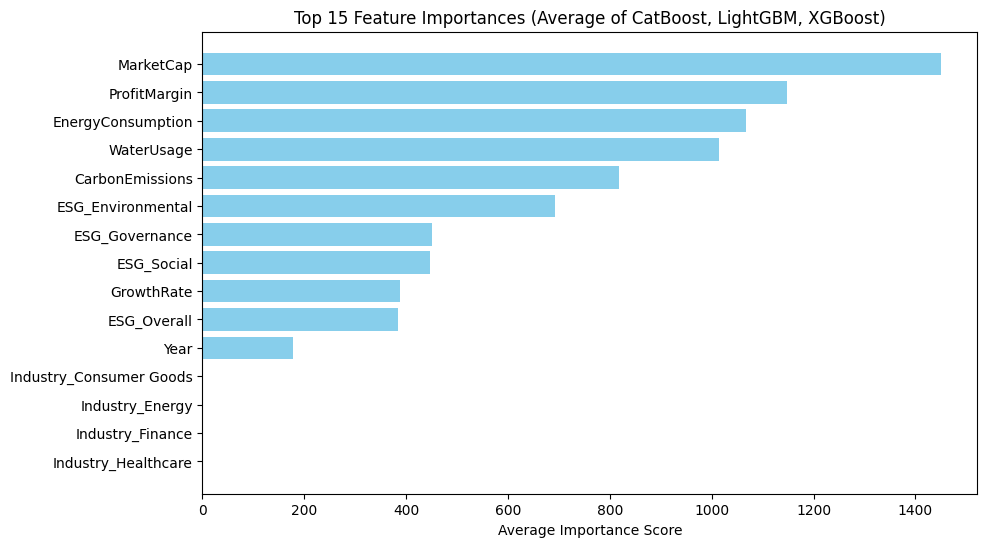

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ✅ Extract best tuned models from the dictionary
cat = best_models['CatBoost']
lgb = best_models['LightGBM']
xgb = best_models['XGBoost']

# ✅ Get feature importances (ensure all have same feature order)
cat_imp = cat.feature_importances_
lgb_imp = lgb.feature_importances_
xgb_imp = xgb.feature_importances_

# ✅ Average feature importances
avg_imp = (cat_imp + lgb_imp + xgb_imp) / 3

# ✅ Combine into DataFrame
feat_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': avg_imp
}).sort_values(by='Importance', ascending=False)

# ✅ Display top 10
print("\n🎯 Top 10 Important Features:")
print(feat_importance.head(10))

# ✅ Visualization
plt.figure(figsize=(10,6))
plt.barh(feat_importance['Feature'][:15], feat_importance['Importance'][:15], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Average of CatBoost, LightGBM, XGBoost)")
plt.xlabel("Average Importance Score")
plt.show()


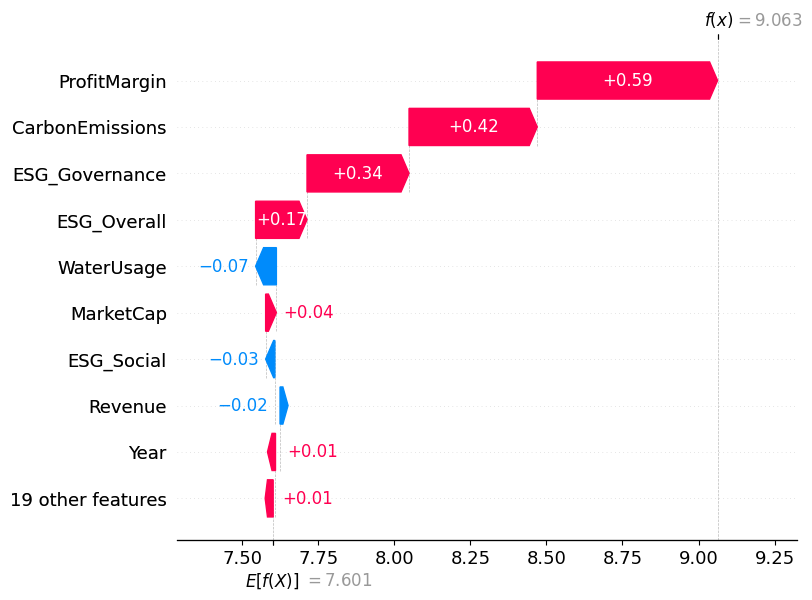

In [108]:
import shap

# Create explainer (use same model)
explainer = shap.TreeExplainer(cat)

# Get SHAP values for the new data
shap_values = explainer.shap_values(df)

# Visualize impact
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    # data=input_df.iloc[0],
    feature_names=df.columns
))


**Understanding Your SHAP Waterfall Plot:**

Base value (expected value) → the model’s average prediction over the training data.
For example: ≈ 3000

f(x) = 3476.202 → the final prediction for this specific input.

Red bars → features that increase the prediction (positive SHAP values).

Blue bars → features that decrease the prediction (negative SHAP values).

The numeric labels (e.g., +582.02) show how much each feature shifted the prediction from the base value.

So this chart basically answers:

“Why did the model predict 3476 instead of the average 3000?”

Similarly, for xgb model.

- The spread of residuals increases slightly for higher predicted values — this pattern (a cone shape) is called heteroscedasticity.

      It means that the variance of prediction errors grows with the predicted value.

      In simpler terms — your model predicts smaller values quite precisely but struggles a bit for very high ones.

- Try log transformation, feature scaling and inspect outliers.

See how each feature influences predictions (positive/negative direction):

Red → higher feature value

Blue → lower feature value

X-axis → effect on prediction